In [ ]:
import pandas as pd

data = pd.read_csv("/content/play_tennis.csv")
data.columns = data.columns.str.strip().str.lower()

attributes = ['outlook', 'temp', 'humidity', 'wind']

S = ['φ'] * 4
G = [['?'] * 4]

def covers(h, x):
    return all(h[i] == '?' or h[i] == x[attributes[i]]
               for i in range(4))

print("=" * 60)
print("CANDIDATE ELIMINATION")
print("=" * 60)

for _, row in data.iterrows():

    x = [row[a] for a in attributes]

    if row['play'] == 'Yes':

        # Generalize S
        for i in range(4):
            if S[i] == 'φ':
                S[i] = x[i]
            elif S[i] != x[i]:
                S[i] = '?'

        # Remove G that do not cover positive example
        G = [g for g in G if covers(g, x)]

        print(f"\n{row['day']} → Positive")
        print("S =", S)
        print("G =", G)

    else:

        print(f"\n{row['day']} → Negative")
        print("Ignored for S")

print("\n" + "=" * 60)
print("FINAL BOUNDARIES")
print("=" * 60)

print("S =", S)
print("G =", G)


CANDIDATE ELIMINATION

D1 → Negative
Ignored for S

D2 → Negative
Ignored for S

D3 → Positive
S = ['Overcast', 'Hot', 'High', 'Weak']
G = [['?', '?', '?', '?']]

D4 → Positive
S = ['?', '?', 'High', 'Weak']
G = [['?', '?', '?', '?']]

D5 → Positive
S = ['?', '?', '?', 'Weak']
G = [['?', '?', '?', '?']]

D6 → Negative
Ignored for S

D7 → Positive
S = ['?', '?', '?', '?']
G = [['?', '?', '?', '?']]

D8 → Negative
Ignored for S

D9 → Positive
S = ['?', '?', '?', '?']
G = [['?', '?', '?', '?']]

D10 → Positive
S = ['?', '?', '?', '?']
G = [['?', '?', '?', '?']]

D11 → Positive
S = ['?', '?', '?', '?']
G = [['?', '?', '?', '?']]

D12 → Positive
S = ['?', '?', '?', '?']
G = [['?', '?', '?', '?']]

D13 → Positive
S = ['?', '?', '?', '?']
G = [['?', '?', '?', '?']]

D14 → Negative
Ignored for S

FINAL BOUNDARIES
S = ['?', '?', '?', '?']
G = [['?', '?', '?', '?']]


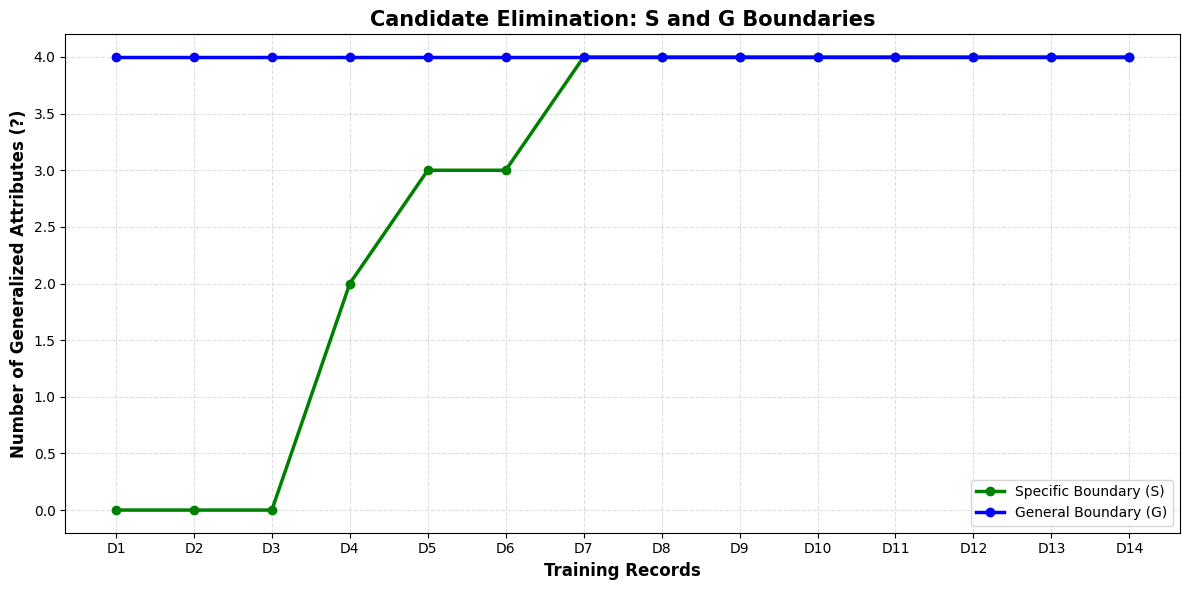

In [ ]:
import matplotlib.pyplot as plt

# ==========================================================
# RE-RUN CANDIDATE ELIMINATION
# ==========================================================

S = ['φ'] * 4
G = [['?'] * 4]

S_history = []
G_history = []

for _, row in data.iterrows():

    x = [row[a] for a in attributes]

    if row['play'] == 'Yes':

        # Update S
        for i in range(4):

            if S[i] == 'φ':
                S[i] = x[i]

            elif S[i] != x[i]:
                S[i] = '?'

        # Remove G that do not cover positive example
        G = [g for g in G if covers(g, x)]

    # Save history
    S_history.append(S.copy())
    G_history.append([g.copy() for g in G])


# ==========================================================
# CALCULATE VALUES FOR GRAPH
# ==========================================================

S_values = []
G_values = []

for s, g_list in zip(S_history, G_history):

    # Number of '?' in S
    s_score = s.count('?')

    # Average number of '?' in G
    if len(g_list) > 0:
        g_score = sum(
            g.count('?') for g in g_list
        ) / len(g_list)
    else:
        g_score = 0

    S_values.append(s_score)
    G_values.append(g_score)


# ==========================================================
# LINE GRAPH
# ==========================================================

plt.figure(figsize=(12, 6))

plt.plot(
    data['day'],
    S_values,
    marker='o',
    linewidth=2.5,
    color='green',
    label='Specific Boundary (S)'
)

plt.plot(
    data['day'],
    G_values,
    marker='o',
    linewidth=2.5,
    color='blue',
    label='General Boundary (G)'
)

# ==========================================================
# GRAPH SETTINGS
# ==========================================================

plt.xlabel(
    "Training Records",
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    "Number of Generalized Attributes (?)",
    fontsize=12,
    fontweight='bold'
)

plt.title(
    "Candidate Elimination: S and G Boundaries",
    fontsize=15,
    fontweight='bold'
)

plt.xticks(data['day'])

plt.grid(
    True,
    linestyle='--',
    alpha=0.4
)

plt.legend()

plt.tight_layout()
plt.show()



--- After Example 1 (('Sunny', 'Hot', 'High', 'Weak') -> No) ---
S (specific boundary): [('0', '0', '0', '0')]
G (general boundary): [('Overcast', '?', '?', '?'), ('?', '?', '?', 'Strong'), ('?', 'Cool', '?', '?'), ('?', '?', 'Normal', '?'), ('?', 'Mild', '?', '?'), ('Rain', '?', '?', '?')]

--- After Example 2 (('Sunny', 'Mild', 'Normal', 'Strong') -> Yes) ---
S (specific boundary): [('Sunny', 'Mild', 'Normal', 'Strong')]
G (general boundary): [('?', '?', '?', 'Strong'), ('?', '?', 'Normal', '?'), ('?', 'Mild', '?', '?')]

--- After Example 3 (('Overcast', 'Cool', 'Normal', 'Weak') -> Yes) ---
S (specific boundary): [('?', '?', 'Normal', '?')]
G (general boundary): [('?', '?', 'Normal', '?')]

--- After Example 4 (('Rain', 'Mild', 'High', 'Weak') -> No) ---
S (specific boundary): [('?', '?', 'Normal', '?')]
G (general boundary): [('?', '?', 'Normal', '?')]

--- After Example 5 (('Rain', 'Cool', 'Normal', 'Weak') -> Yes) ---
S (specific boundary): [('?', '?', 'Normal', '?')]
G (genera

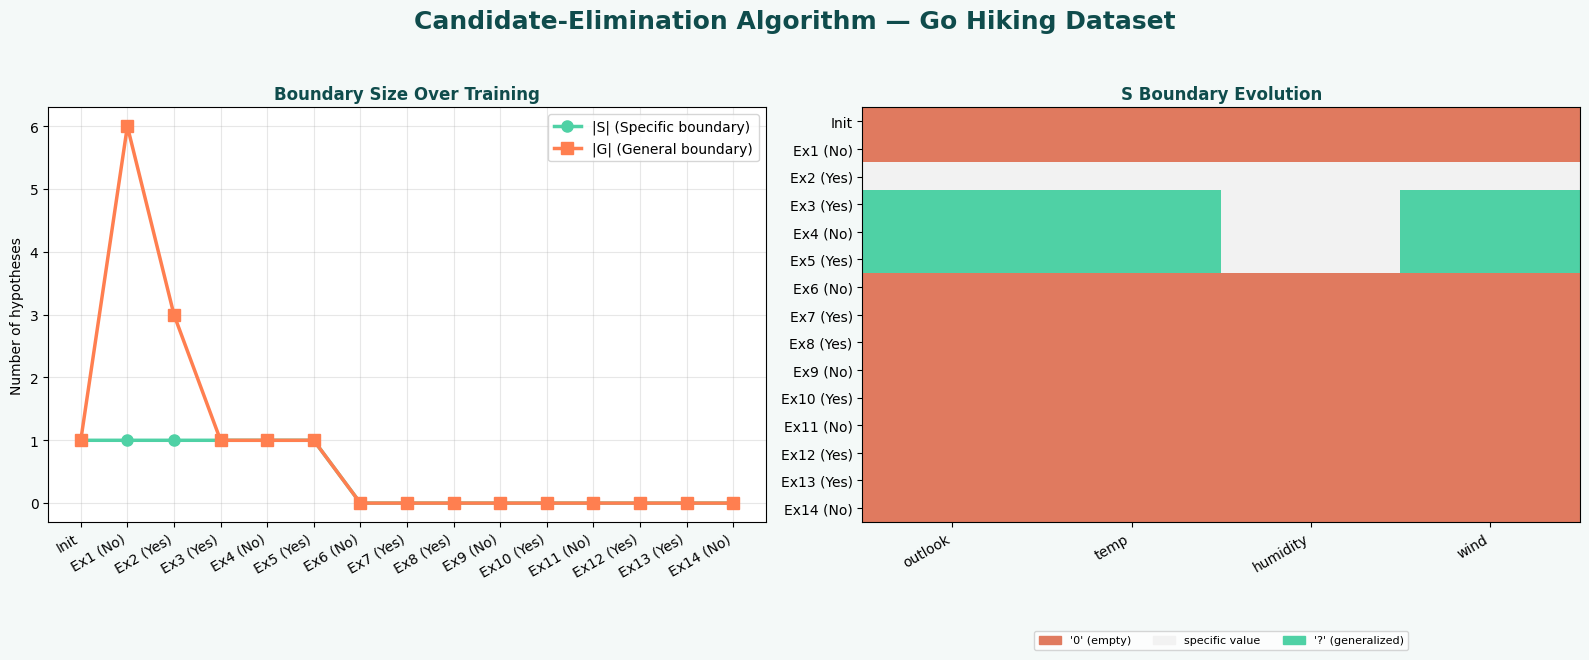

In [ ]:
"""
Candidate-Elimination Algorithm
Dataset: Go Hiking
Includes full analysis visualizations for classroom discussion.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# ---------------------------------------------------------
# 1. DATASET
# ---------------------------------------------------------
attributes = ['outlook', 'temp', 'humidity', 'wind']

data = [
    ['Sunny',    'Hot',  'High',   'Weak',   'No'],   # H1
    ['Sunny',    'Mild', 'Normal', 'Strong', 'Yes'],  # H2
    ['Overcast', 'Cool', 'Normal', 'Weak',   'Yes'],  # H3
    ['Rain',     'Mild', 'High',   'Weak',   'No'],   # H4
    ['Rain',     'Cool', 'Normal', 'Weak',   'Yes'],  # H5
    ['Rain',     'Cool', 'Normal', 'Strong', 'No'],   # H6
    ['Overcast', 'Hot',  'Normal', 'Strong', 'Yes'],  # H7
    ['Sunny',    'Cool', 'Normal', 'Weak',   'Yes'],  # H8
    ['Sunny',    'Mild', 'High',   'Strong', 'No'],   # H9
    ['Overcast', 'Mild', 'Normal', 'Weak',   'Yes'],  # H10
    ['Rain',     'Hot',  'High',   'Strong', 'No'],   # H11
    ['Sunny',    'Mild', 'Normal', 'Weak',   'Yes'],  # H12
    ['Overcast', 'Hot',  'High',   'Weak',   'Yes'],  # H13
    ['Rain',     'Mild', 'Normal', 'Strong', 'No'],   # H14
]

X = [row[:-1] for row in data]
y = [row[-1] for row in data]
n_attributes = len(attributes)

# ---------------------------------------------------------
# 2. HELPER FUNCTIONS
# ---------------------------------------------------------
def more_general(h1, h2):
    for x, y_ in zip(h1, h2):
        if x == '?': continue
        if x == '0': return False
        if y_ == '0': continue
        if x != y_: return False
    return True

def consistent(h, instance):
    for hx, ix in zip(h, instance):
        if hx == '?': continue
        if hx == '0': return False
        if hx != ix: return False
    return True

def min_generalizations(h, instance):
    new_h = list(h)
    for i in range(len(h)):
        if h[i] == '0':
            new_h[i] = instance[i]
        elif h[i] != instance[i]:
            new_h[i] = '?'
    return [tuple(new_h)]

def min_specializations(h, domains, instance):
    results = []
    for i in range(len(h)):
        if h[i] == '?':
            for val in domains[i]:
                if val != instance[i]:
                    new_h = list(h)
                    new_h[i] = val
                    results.append(tuple(new_h))
    return results

def remove_more_general(hyps):
    return [h for h in hyps if not any(h != h2 and more_general(h2, h) for h2 in hyps)]

def remove_less_general(hyps):
    return [h for h in hyps if not any(h != h2 and more_general(h, h2) for h2 in hyps)]

# ---------------------------------------------------------
# 3. CANDIDATE-ELIMINATION ALGORITHM
# ---------------------------------------------------------
def candidate_elimination(X, y, attributes):
    domains = [sorted(set(row[i] for row in X)) for i in range(len(attributes))]
    S = [tuple(['0'] * n_attributes)]
    G = [tuple(['?'] * n_attributes)]

    history = {'S_sizes':[len(S)], 'G_sizes':[len(G)], 'S_sets':[list(S)], 'G_sets':[list(G)], 'labels':['Init']}

    for idx,(instance,label) in enumerate(zip(X,y)):
        instance = tuple(instance)
        if label == 'Yes':
            G = [g for g in G if consistent(g, instance)]
            new_S = []
            for s in S:
                if consistent(s, instance):
                    new_S.append(s)
                else:
                    for h in min_generalizations(s, instance):
                        if any(more_general(g, h) for g in G):
                            new_S.append(h)
            S = remove_more_general(list(set(new_S)))
        else:
            S = [s for s in S if not consistent(s, instance)]
            new_G = []
            for g in G:
                if not consistent(g, instance):
                    new_G.append(g)
                else:
                    for h in min_specializations(g, domains, instance):
                        if any(more_general(h, s) for s in S):
                            new_G.append(h)
            G = remove_less_general(list(set(new_G)))

        history['S_sizes'].append(len(S))
        history['G_sizes'].append(len(G))
        history['S_sets'].append(list(S))
        history['G_sets'].append(list(G))
        history['labels'].append(f'Ex{idx+1} ({label})')

        print(f"\n--- After Example {idx+1} ({instance} -> {label}) ---")
        print("S (specific boundary):", S if S else "{}")
        print("G (general boundary):", G if G else "{}")

    return S, G, history

# ---------------------------------------------------------
# 4. RUN
# ---------------------------------------------------------
S_final, G_final, history = candidate_elimination(X, y, attributes)
print("\nFINAL SPECIFIC BOUNDARY (S):", S_final)
print("FINAL GENERAL BOUNDARY (G):", G_final)

# ---------------------------------------------------------
# 5. VISUALIZATION
# ---------------------------------------------------------
COL_TEAL = '#0f4c4c'; COL_MINT = '#4fd1a5'; COL_LIGHT = '#a8e6cf'; COL_ACCENT = '#ff7f50'; COL_BG = '#f4f9f8'

def specificity_score(h):
    return [(-1 if v=='0' else 1 if v=='?' else 0) for v in h]

fig = plt.figure(figsize=(16,11), facecolor=COL_BG)
fig.suptitle('Candidate-Elimination Algorithm — Go Hiking Dataset', fontsize=18, fontweight='bold', color=COL_TEAL, y=0.98)

# Plot 1: Boundary size trend
ax1 = plt.subplot(2,2,1)
steps = range(len(history['S_sizes']))
ax1.plot(steps, history['S_sizes'], marker='o', color=COL_MINT, linewidth=2.5, label='|S| (Specific boundary)', markersize=8)
ax1.plot(steps, history['G_sizes'], marker='s', color=COL_ACCENT, linewidth=2.5, label='|G| (General boundary)', markersize=8)
ax1.set_xticks(steps); ax1.set_xticklabels(history['labels'], rotation=30, ha='right')
ax1.set_ylabel('Number of hypotheses'); ax1.set_title('Boundary Size Over Training', color=COL_TEAL, fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_facecolor('white')

# Plot 2: S boundary evolution heatmap
ax2 = plt.subplot(2,2,2)
s_track = [specificity_score(s_set[0] if s_set else tuple(['0']*n_attributes)) for s_set in history['S_sets']]
s_matrix = np.array(s_track)
cmap = ListedColormap(['#e07a5f','#f2f2f2',COL_MINT])
ax2.imshow(s_matrix, aspect='auto', cmap=cmap, vmin=-1, vmax=1)
ax2.set_xticks(range(n_attributes)); ax2.set_xticklabels(attributes, rotation=30, ha='right')
ax2.set_yticks(range(len(history['labels']))); ax2.set_yticklabels(history['labels'])
ax2.set_title('S Boundary Evolution', color=COL_TEAL, fontweight='bold')
patches = [mpatches.Patch(color='#e07a5f', label="'0' (empty)"),
           mpatches.Patch(color='#f2f2f2', label='specific value'),
           mpatches.Patch(color=COL_MINT, label="'?' (generalized)")]
ax2.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5,-0.25), ncol=3, fontsize=8)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('candidate_elimination_go_hiking_analysis.png', dpi=150, facecolor=COL_BG)
plt.show()
